This notebook attemps to replicate the analysis done in NPS's climate future project for various levels of downscaled CMIP6 data

In [7]:
import xarray as xr
import geopandas as gpd
import pandas as pd
import rioxarray as rxr
from shapely.geometry import mapping
import matplotlib.pyplot as plt

In [2]:
# Load the dataset and inspect its structure
nc = xr.open_dataset('isimip/data/processed/gfdl-esm4_r1i1p1f1_w5e5_historical_pr_jotr_monthly.nc', engine="netcdf4")
nc

<xarray.Dataset> Size: 95kB
Dimensions:    (time: 1980, bnds: 2, lon: 3, lat: 2)
Coordinates:
  * time       (time) datetime64[ns] 16kB 1850-01-16 ... 2014-12-16
  * lon        (lon) float64 24B -116.2 -115.8 -115.2
  * lat        (lat) float64 16B 34.25 33.75
Dimensions without coordinates: bnds
Data variables:
    time_bnds  (time, bnds) datetime64[ns] 32kB ...
    pr         (time, lat, lon) float32 48kB ...
Attributes:
    CDI:          Climate Data Interface version 2.5.0 (https://mpimet.mpg.de...
    Conventions:  CF-1.6
    institution:  Potsdam Institute for Climate Impact Research (PIK)
    contact:      ISIMIP cross-sectoral science team <info@isimip.org> <https...
    references:   Lange (2019) <https://doi.org/10.5194/gmd-12-3055-2019> and...
    title:        ISIMIP3b bias-adjusted climate input data
    project:      Inter-Sectoral Impact Model Intercomparison Project phase 3...
    summary:      CMIP6 daily output data bias-adjusted and statistically dow...
    history:      Fri Jan 30 17:40:16 2026: cdo mergetime gfdl-esm4_r1i1p1f1_...
    frequency:    mon
    CDO:          Climate Data Operators version 2.5.0 (https://mpimet.mpg.de...

In [3]:
# crop to only pixels inside park boundary

def crop_to_park_boundary(nc, boundary, variable):
    ''' Takes an xarray object and crops within the provided boundary (geopandas), 
    returning a clipped xarray object. '''
    
    # Select just the precipitation variable (time_bnds doesn't have spatial dims)
    nc_pr = nc[variable].rio.set_spatial_dims(x_dim="lon", y_dim="lat")
    nc_pr = nc_pr.rio.write_crs("EPSG:4326", inplace=True)
    if nc_pr.rio.crs != boundary.crs:
        boundary = boundary.to_crs(nc_pr.rio.crs)
    nc_clipped = nc_pr.rio.clip(boundary.geometry.values, boundary.crs, drop=True, all_touched=True)

    return(nc_clipped)

def calculate_anomaly(scenario, baseline_period, model, variable, boundary):
    ''' Takes a clipped xarray object and calculates the anomaly relative to the provided baseline period. 
    Returns an xarray object of the anomaly. '''
    nc = xr.open_dataset(f'isimip/data/processed/{model}_w5e5_{scenario}_{variable}_jotr_monthly.nc', engine="netcdf4")
    nc_clipped = crop_to_park_boundary(nc, boundary, variable)
    nc_hist = xr.open_dataset(f'isimip/data/processed/{model}_w5e5_historical_{variable}_jotr_monthly.nc', engine="netcdf4")
    nc_hist_clipped = crop_to_park_boundary(nc_hist, boundary, variable)
    ts_hist = nc_hist_clipped.mean(("lon", "lat"))
    baseline = ts_hist.sel(time=slice(baseline_period[0], baseline_period[1])).mean("time")
    anomaly = nc_clipped.mean(("lon", "lat")) - baseline
    return(anomaly)

# spatially aggregate to average yearly timeseries
def plot_clipped_timeseries(ax, scenario, model, boundary, variable):

    if scenario == "historical":
        color = "blue"
    elif scenario == "ssp126":
        color = "orange"
    elif scenario == "ssp585":
        color = "red"

    try:
        anomaly = calculate_anomaly(scenario, ("1979", "2012"), model, variable, boundary)
        
        anomaly.plot(ax=ax, label=f"{model.split('_')[0]} {scenario}", color=color, alpha=0.7)
    except FileNotFoundError:
        print(f"File not found: {model} {scenario}")

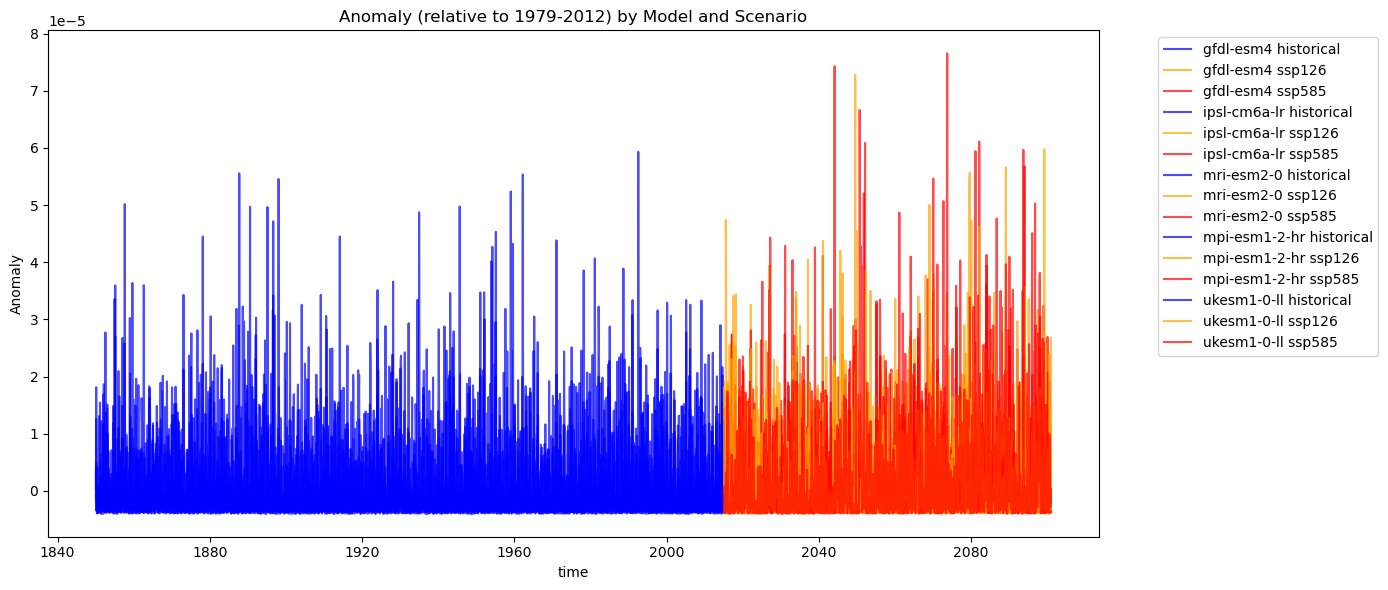

In [5]:
boundary = gpd.read_file('isimip/data/Joshua_Tree_National_Park.shp')

fig, ax = plt.subplots(figsize=(14, 6))

for model in ['gfdl-esm4_r1i1p1f1', 'ipsl-cm6a-lr_r1i1p1f1', 'mri-esm2-0_r1i1p1f1', 'mpi-esm1-2-hr_r1i1p1f1', 'ukesm1-0-ll_r1i1p1f2']:
    for scenario in ["historical", "ssp126", "ssp585"]:
        plot_clipped_timeseries(ax, scenario, model, boundary, 'pr')

ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax.set_title('Anomaly (relative to 1979-2012) by Model and Scenario')
ax.set_ylabel('Anomaly')
plt.tight_layout()
plt.show()

In [6]:
#Calculate mid-century anomalies

def mid_century_anomalies(scenario, model, variable, boundary):
    anomaly = calculate_anomaly(scenario, ("1979", "2012"), model, variable, boundary)
    mid_century_anomaly = anomaly.sel(time=slice("2035", "2065")).mean("time")
    return(mid_century_anomaly)

mid_century_anomalies("ssp585", "gfdl-esm4_r1i1p1f1", 'pr', boundary)




<xarray.DataArray 'pr' ()> Size: 8B
array(-6.51392469e-07)
Coordinates:
    spatial_ref  int64 8B 0

In [11]:
boundary = gpd.read_file('isimip/data/Joshua_Tree_National_Park.shp')

park = 'jotr'
all_data = []

for model in ['ukesm1-0-ll_r1i1p1f2', 'gfdl-esm4_r1i1p1f1', 'ipsl-cm6a-lr_r1i1p1f1', 'mri-esm2-0_r1i1p1f1', 'mpi-esm1-2-hr_r1i1p1f1']:
    for scenario in ['ssp126', 'ssp585']:
        anomaly_tas = mid_century_anomalies(scenario, model, 'tas', boundary)
        anomaly_pr = mid_century_anomalies(scenario, model, 'pr', boundary)
        data = {
            'model': model,
            'scenario': scenario,
            'park': park,
            'anomaly_tas': anomaly_tas.item(),
            'anomaly_pr': anomaly_pr.item()
        }

        all_data.append(data)

df = pd.DataFrame(all_data)

print(df.head())

df.to_csv(f'climate_future_{park}.csv')


                   model scenario  park  anomaly_tas    anomaly_pr
0   ukesm1-0-ll_r1i1p1f2   ssp126  jotr     2.758796  8.960002e-07
1   ukesm1-0-ll_r1i1p1f2   ssp585  jotr     3.795265  2.178875e-06
2     gfdl-esm4_r1i1p1f1   ssp126  jotr     1.477539 -3.212296e-07
3     gfdl-esm4_r1i1p1f1   ssp585  jotr     2.086693 -6.513925e-07
4  ipsl-cm6a-lr_r1i1p1f1   ssp126  jotr     1.609119 -8.357188e-08
